# 실습 1. KMeans 군집화

Breast Cancer 데이터셋을 사용해 KMeans 군집화 흐름을 복습함.

## 데이터셋
- 데이터: scikit-learn `load_breast_cancer`
- 샘플 수: 569개
- feature 수: 30개
- target: `malignant`, `benign`

KMeans 학습에는 target을 사용하지 않음. target은 군집 결과를 나중에 해석하기 위한 비교 기준으로만 사용함.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

cancer = load_breast_cancer(as_frame=True)
cancer_X = cancer.data.copy()
cancer_y = cancer.target.copy()
cancer_target_names = dict(enumerate(cancer.target_names))

cancer_df = cancer_X.copy()
cancer_df['target'] = cancer_y
cancer_df['target_name'] = cancer_df['target'].map(cancer_target_names)

display(cancer_df.head())
print('feature shape:', cancer_X.shape)
print('target shape:', cancer_y.shape)
print('target names:', cancer.target_names)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


feature shape: (569, 30)
target shape: (569,)
target names: ['malignant' 'benign']


## 문제 1. KMeans 전 스케일링

KMeans는 거리 기반 알고리즘이므로 `StandardScaler`로 feature 스케일을 맞추세요.

요구사항:
- 변수명은 `cancer_scaler`, `cancer_X_scaled` 사용
- 스케일링된 데이터의 평균과 표준편차 확인

### 실행 결과
```text
scaled mean: 0.0
scaled std: 1.0
```


In [3]:
cancer_scaler = StandardScaler()
cancer_X_scaled = cancer_scaler.fit_transform(cancer_X)

print("scaled mean: ", round(cancer_X_scaled.mean(), 4))
print("scaled std: ", round(cancer_X_scaled.std(), 4))

scaled mean:  -0.0
scaled std:  1.0


## 문제 2. KMeans 기본 군집화

`KMeans(n_clusters=2)`로 Breast Cancer 데이터를 2개 군집으로 나누세요.

요구사항:
- 변수명은 `cancer_kmeans`, `cancer_cluster_labels` 사용
- 결과를 `cancer_cluster_df`에 저장
- 군집별 샘플 개수와 `inertia_` 확인

### 실행 결과
```text
cluster count 예시
0    375
1    194
inertia: 11595.527
```


In [13]:
cancer_kmeans = KMeans(n_clusters=2)
cancer_cluster_labels = cancer_kmeans.fit_predict(cancer_X_scaled)
cancer_cluster_df = pd.DataFrame(cancer_cluster_labels, columns=['cluster'])
print(cancer_cluster_df['cluster'].value_counts())
print("inertia: ", cancer_kmeans.inertia_)

cluster
0    381
1    188
Name: count, dtype: int64
inertia:  11595.683312822137


## 문제 3. 실제 target과 군집 결과 비교

KMeans는 target 없이 학습했지만, 실습 데이터에는 실제 target이 있으므로 교차표로 비교할 수 있음.

요구사항:
- `pd.crosstab()` 사용
- 행은 실제 class, 열은 KMeans cluster
- 결과 변수명은 `cancer_cluster_table` 사용

### 실행 결과
```text
cluster         0    1
actual_class          
benign        339   18
malignant      36  176
```


In [15]:
cancer_cluster_table = pd.crosstab(
    index=cancer_df['target_name'],
    columns=cancer_cluster_df['cluster'],
    rownames=['actual_class'],
    colnames=['cluster']
)

display(cancer_cluster_table)

cluster,0,1
actual_class,,
benign,344,13
malignant,37,175


## 문제 4. PCA 2차원 시각화

30개 feature를 PCA 2차원으로 줄여 실제 class와 KMeans cluster를 나란히 시각화하세요.

요구사항:
- `PCA(n_components=2)` 사용
- 왼쪽 그래프는 실제 class, 오른쪽 그래프는 cluster 기준 색상

### 실행 결과
```text
확인 포인트: 실제 class 분포와 KMeans cluster 분포가 얼마나 비슷한지 비교
```
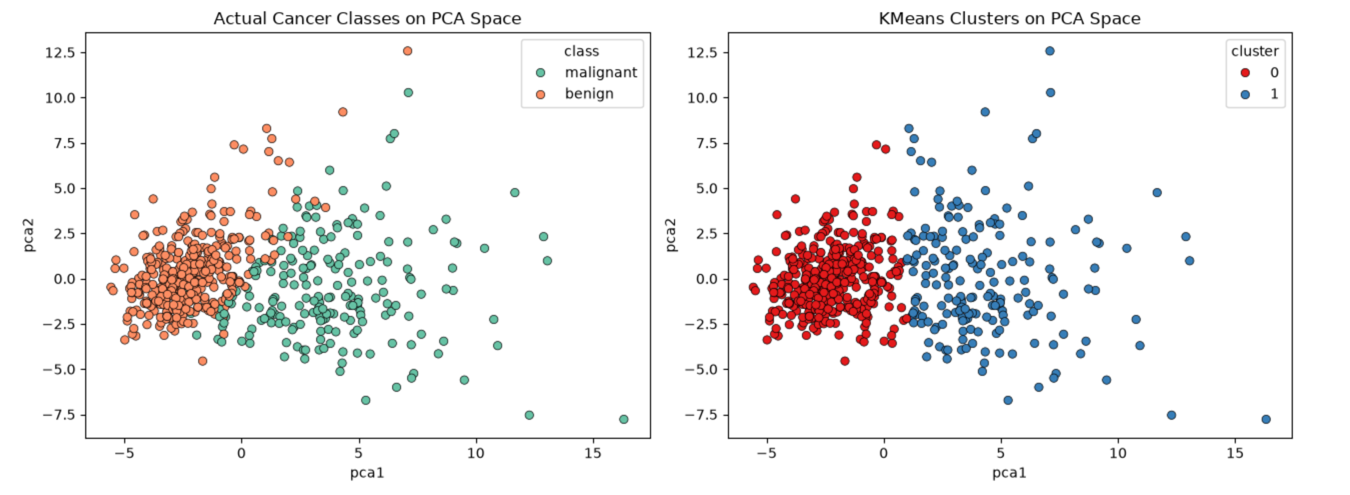


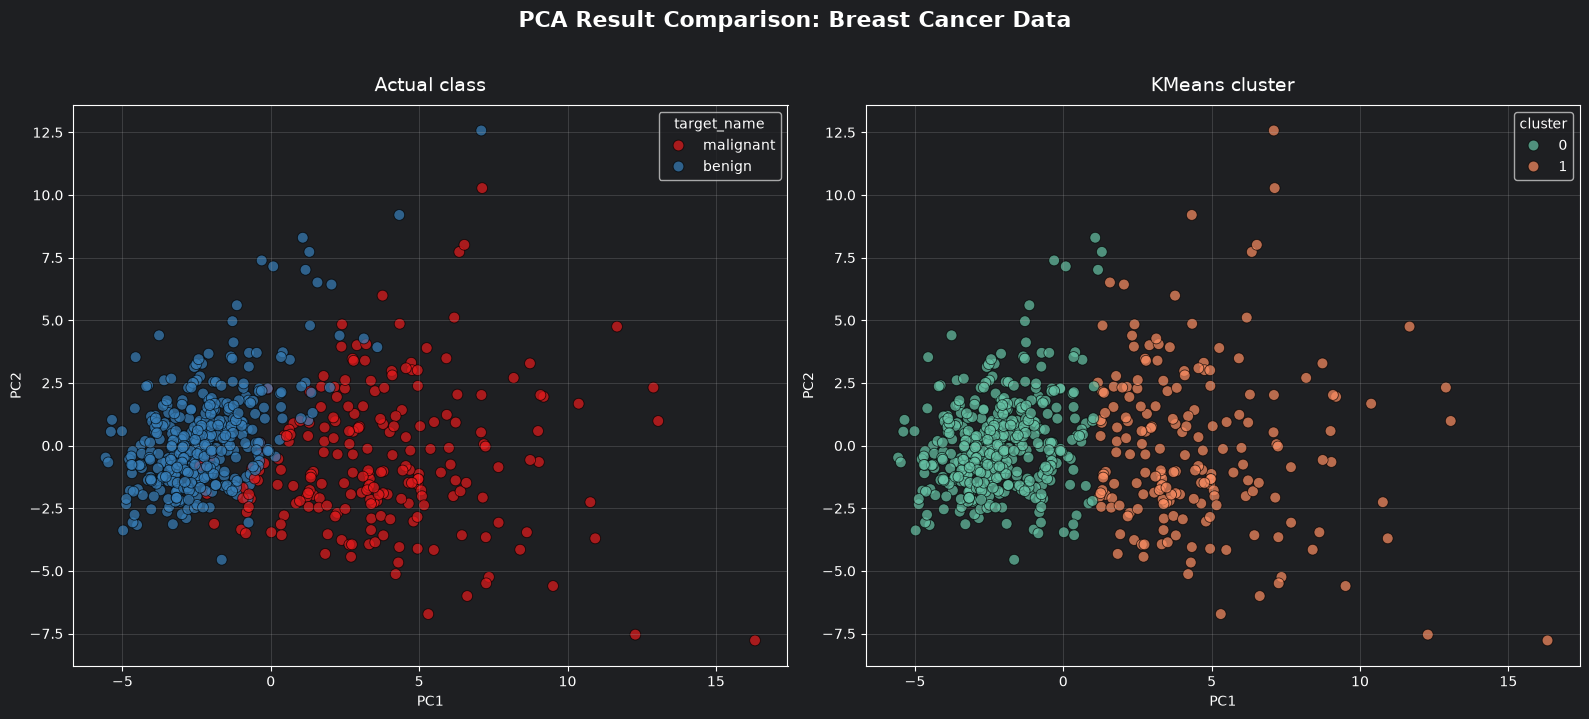

In [7]:
pca = PCA(n_components=2)
cancer_pca = pca.fit_transform(cancer_X_scaled)

pca_df = pd.DataFrame(cancer_pca, columns=['PC1', 'PC2'])
pca_df['target_name'] = cancer_df['target_name'].to_numpy()
pca_df['cluster'] = cancer_cluster_labels

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='target_name',
    palette='Set1',       # 색상 조합 지정 (변경 가능)
    edgecolor='black',
    alpha=0.7,
    s=60,
    ax=axes[0]            # 첫 번째 칸에 배치
)
axes[0].set_title('Actual class', fontsize=14, pad=10)
axes[0].grid(True, alpha=0.3)

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2',       # 색상 조합 다르게 지정해서 구분감 주기
    edgecolor='black',
    alpha=0.7,
    s=60,
    ax=axes[1]            # 두 번째 칸에 배치
)
axes[1].set_title('KMeans cluster', fontsize=14, pad=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA Result Comparison: Breast Cancer Data', fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 문제 5. k 후보별 inertia와 silhouette score 비교

`k=2`부터 `k=6`까지 KMeans를 학습하고 inertia와 silhouette score를 비교하세요.

요구사항:
- 결과 변수명은 `cancer_k_result_df` 사용
- `inertia`, `silhouette_score` 컬럼 포함

### 실행 결과
```text
   k     inertia  silhouette_score
0  2  11595.5266            0.3434
1  3  10061.7978            0.3144
2  4   9258.9891            0.2833
3  5   8558.6607            0.1582
4  6   7970.2638            0.1604
```


In [8]:
cancer_k_result_df = pd.DataFrame(columns=['k', 'inertia', 'silhouette_score'])

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(cancer_X_scaled)

    inertia_val = kmeans.inertia_
    sil_score = silhouette_score(cancer_X_scaled, cluster_labels)

    cancer_k_result_df.loc[len(cancer_k_result_df)] = [
        int(k),
        round(inertia_val, 4),
        round(sil_score, 4)
    ]

cancer_k_result_df['k'] = cancer_k_result_df['k'].astype(int)

display(cancer_k_result_df)

,k,inertia,silhouette_score
0,2,11595.6833,0.3447
1,3,10066.2818,0.3152
2,4,9266.1542,0.2742
3,5,9263.4048,0.1645
4,6,8562.8788,0.1451
